# Radiation Comparison between Models 

Short wave solar radiation is biologically important. Would be a great idea to compare it in different models, especially `HRDPS` and `CaSR`.



## Construct year-averaged files



### CaSR

CaSR file names:

    Integrated_RDPS_P_FB_SFC_2008_2024.nc   Integrated_RDPS_P_PR0_SFC_2008_2024.nc
    Integrated_RDPS_P_FI_SFC_2008_2024.nc   Integrated_RDPS_P_TT_1.5m_2008_2024.nc
    Integrated_RDPS_P_HU_1.5m_2008_2024.nc  Integrated_RDPS_P_UUC_10m_2008_2024.nc
    Integrated_RDPS_P_PN_SFC_2008_2024.nc   Integrated_RDPS_P_VVC_10m_2008_2024.nc

Base path: `/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/`

In [1]:
import xarray as xr

path_casr='/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_FB_SFC_2008_2024.nc'

ds_casr=xr.open_dataset(path_casr)

In [5]:
import sys

sys.path.append("/home/jqiu/analysis-junqi/Tools-Junqi")

import junqi_nctool as jqnc

jqnc.nc_disp(path_casr,detailed=True)

### NetCDF Summary

*Path: : `/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_FB_SFC_2008_2024.nc`*

#### Dimensions

Dimension,Size
time,149040
rlat,105
rlon,70


#### Variables

Name,Shape,Dimensions,Long Name,Units
rotated_pole,(),scalar,,
CaSR_v3.2_P_FB_SFC,"(149040, 105, 70)","time, rlat, rlon",Forecast: Downward solar flux at surface,W m**-2
time,"(149040,)",time,Validity time,
lon,"(105, 70)","rlat, rlon",longitude,degrees_east
lat,"(105, 70)","rlat, rlon",latitude,degrees_north
rlon,"(70,)",rlon,longitude in rotated pole grid,degrees
rlat,"(105,)",rlat,latitude in rotated pole grid,degrees


#### Global Attributes

Attribute,Value
Conventions,CF-1.6
source,https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/
institution,Environment and Climate Change Canada / Environnement et Changement climatique Canada
title,Canadian Surface Reanalysis (CaSR) / Réanalyse Canadienne de Surface (RCaS)
contact,rcas-casr@ec.gc.ca
licence,These data are produced and provided by the Environment and Climate Change Canada. License agreement can be found in https://open.canada.ca/en/open-government-licence-canada or email rcas-casr@ec.gc.ca / Ces données sont produites et fournies par Environnement et Changement climatique Canada. Le contrat de license peut être trouvé dans https://ouvert.canada.ca/fr/licence-du-gouvernement-ouvert-canada ou courriel rcas-casr@ec.gc.ca


In [8]:
# calculate year mean

import numpy as np


ds_casr.sel(time=slice('2018-01-01','2018-12-31'))

solar_radiation=ds_casr['CaSR_v3.2_P_FB_SFC']
mean_solar_radiation=solar_radiation.mean(dim='time')

mean_casr_2018=xr.Dataset({
    'mean_solar_radiation': mean_solar_radiation
})

# save 

output_path = "casr_2018_solar_radiation.nc"

mean_casr_2018.to_netcdf(output_path)

### HRDPS



In [9]:
# combine hrdps dataset

import xarray as xr

def variables(ds):
    return ds[['solar','nav_lat','nav_lon']]

ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})

# calculate velocity related variables

import numpy as np
from dask.distributed import Client

# real time progress (recommended by Gemini)
client = Client() 
print(f"Dask Dashboard link: {client.dashboard_link}")

solar_radiation=ds_hrdps['solar']


# calculate mean

mean_solar_radiation=solar_radiation.mean(dim='time_counter')


mean_hrdps_2018=xr.Dataset({
    'mean_solar_radiation': mean_solar_radiation,
    'nav_lat': ds_hrdps['nav_lat'].isel(time_counter=0),
    'nav_lon': ds_hrdps['nav_lon'].isel(time_counter=0)
})

# save

output_path = "hrdps_2018_solar_radiation.nc"

mean_hrdps_2018.to_netcdf(output_path)

/tmp/ipykernel_3417959/2434827939.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})


Dask Dashboard link: http://127.0.0.1:8787/status


## Visualization: map



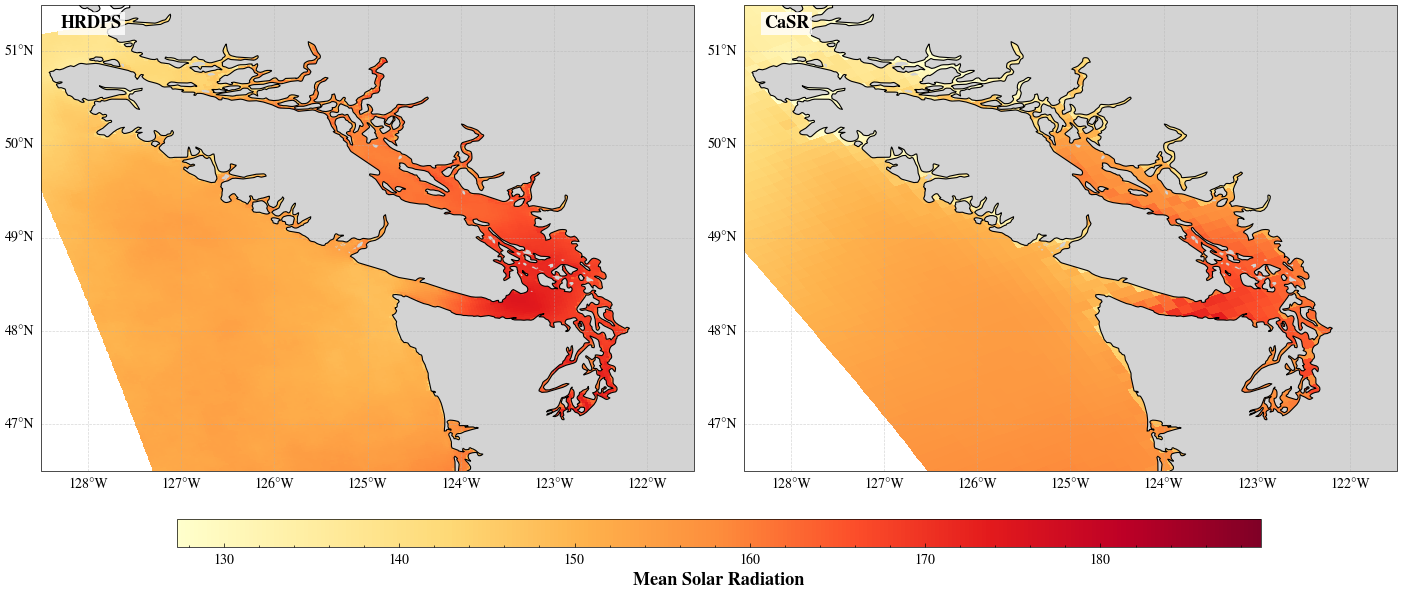

In [15]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import scienceplots

# 启用 SciencePlots 风格
plt.style.use(['science', 'no-latex'])

# =========================
# Load data
# =========================

ds_h = xr.open_dataset("hrdps_2018_solar_radiation.nc")
ds_c = xr.open_dataset("casr_2018_solar_radiation.nc")

# HRDPS
lon_h = ds_h.nav_lon.values
lat_h = ds_h.nav_lat.values
solar_h = ds_h.mean_solar_radiation.values

# CASR
lon_c = ds_c.lon.values
lat_c = ds_c.lat.values
solar_c = ds_c.mean_solar_radiation.values


# =========================
# Convert longitude if needed
# e.g. 233E -> -127W
# =========================

def fix_lon(lon):
    return np.where(lon > 180, lon - 360, lon)

lon_h = fix_lon(lon_h)
lon_c = fix_lon(lon_c)


# =========================
# Auto map extent from both datasets
# =========================

lon_all = np.concatenate([lon_h.ravel(), lon_c.ravel()])
lat_all = np.concatenate([lat_h.ravel(), lat_c.ravel()])

lon_min = -128
lon_max = -122
lat_min = 47
lat_max = 51

# Add small padding
lon_pad = 0.5
lat_pad = 0.5

extent = [
    lon_min - lon_pad,
    lon_max + lon_pad,
    lat_min - lat_pad,
    lat_max + lat_pad
]


# =========================
# Shared color scale
# =========================

solar_all = np.concatenate([solar_h.ravel(), solar_c.ravel()])
vmin = np.nanpercentile(solar_all, 1)
vmax = np.nanpercentile(solar_all, 99)


# =========================
# Visualization: 1 x 2
# =========================

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 6),
    subplot_kw={"projection": proj},
    layout="constrained"
)


def setup_map(ax):
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)

    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False


# =========================
# HRDPS
# =========================

ax1 = axes[0]
setup_map(ax1)

pcm1 = ax1.pcolormesh(
    lon_h,
    lat_h,
    solar_h,
    transform=proj,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
    zorder=1
)

ax1.text(
    0.03,
    0.95,
    "HRDPS",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    zorder=10
)


# =========================
# CASR
# =========================

ax2 = axes[1]
setup_map(ax2)

pcm2 = ax2.pcolormesh(
    lon_c,
    lat_c,
    solar_c,
    transform=proj,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
    zorder=1
)

ax2.text(
    0.03,
    0.95,
    "CaSR",
    transform=ax2.transAxes,
    fontsize=13,
    fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    zorder=10
)


# =========================
# Shared colorbar
# =========================

cb = fig.colorbar(
    pcm1,
    ax=axes,
    orientation="horizontal",
    aspect=40,
    shrink=0.8,
    pad=0.05
)

cb.set_label("Mean Solar Radiation", fontsize=13, fontweight="bold")

plt.show()

## Visualization (scatter plot)



### Constructing data


In [19]:
# Scatter Plot within the Salish Sea

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# Matching lon lim
def normalize_lon(lon):
    return (lon + 180) % 360 - 180

# paths
path_casr = 'casr_2018_solar_radiation.nc'
path_hrdps = 'hrdps_2018_solar_radiation.nc'
path_bathy = '/data/nsoontie/MEOPAR/NEMO-forcing/grid/bathy_meter_SalishSea2.nc'

# load datasets
ds_casr = xr.open_dataset(path_casr)
ds_hrdps = xr.open_dataset(path_hrdps)
ds_bathy = xr.open_dataset(path_bathy)

# valid coordinates bathy>0
bathy_vals = ds_bathy['Bathymetry'].values[::8, ::8]
mask_water = bathy_vals > 0

nav_lon_sub = ds_bathy['nav_lon'].values[::8, ::8]
nav_lat_sub = ds_bathy['nav_lat'].values[::8, ::8]

water_lon = normalize_lon(nav_lon_sub[mask_water])
water_lat = nav_lat_sub[mask_water]

target_coords = np.column_stack((water_lon, water_lat))


def get_model_matched_data(ds, lon_var, lat_var, target_coords, var_names):
    """
    ds: xarray Dataset
    lon_var: longitude 变量名
    lat_var: latitude 变量名
    target_coords: 目标坐标数组
    var_names: 需要提取的变量名列表，如 ['mean_velocity', 'mean_velocity_squared']
    """
    model_lon = normalize_lon(ds[lon_var].values.flatten())
    model_lat = ds[lat_var].values.flatten()
    
    # get rid of nan in coordinates
    valid_coord_mask = ~(np.isnan(model_lon) | np.isnan(model_lat))
    model_lon = model_lon[valid_coord_mask]
    model_lat = model_lat[valid_coord_mask]
    
    # Build tree and query only ONCE
    tree = cKDTree(np.column_stack((model_lon, model_lat)))
    distances, indices = tree.query(target_coords)
    
    # extract all requested variables
    matched_results = []
    for var in var_names:
        model_var = ds[var].values.flatten()
        # 应用相同的空间 mask
        model_var = model_var[valid_coord_mask]
        # 根据 KDTree 的结果提取数据
        matched_results.append(model_var[indices])
        
    # 如果只请求了一个变量，直接返回该变量；如果请求了多个，返回元组便于解包
    if len(matched_results) == 1:
        return matched_results[0]
    else:
        return tuple(matched_results)



# coordinate matching

# 提取 HRDPS 的三个变量
hrdps_solar_radiation_mean = get_model_matched_data(
    ds_hrdps, 'nav_lon', 'nav_lat', target_coords, 
    ['mean_solar_radiation']
)

# 提取 CASR 的平均值
casr_solar_radiation_mean = get_model_matched_data(
    ds_casr, 'lon', 'lat', target_coords, 
    ['mean_solar_radiation']
)



### Scatter Plot



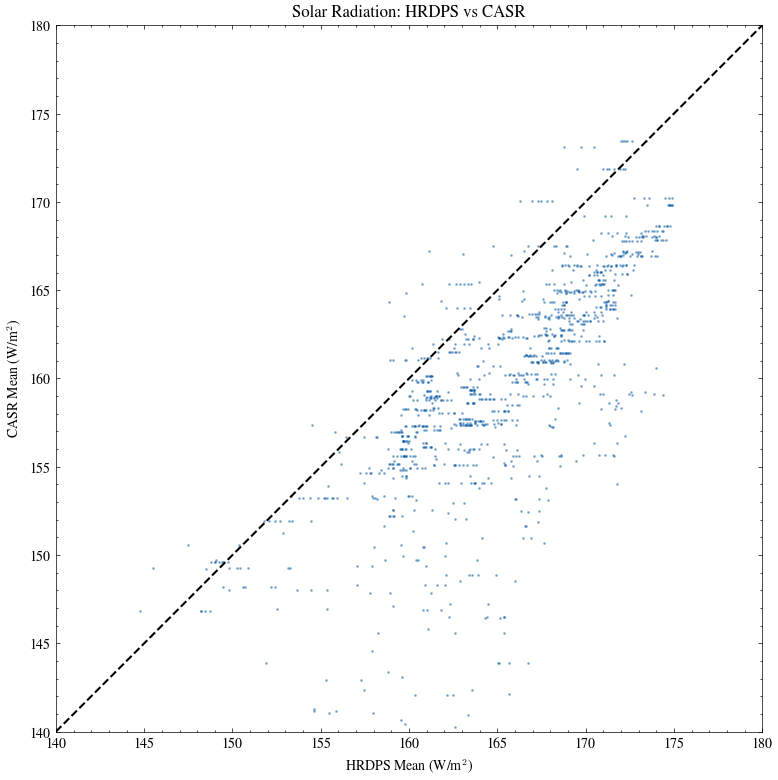

In [23]:
# Scatter Plot for Absolute Wind Speed Mean

import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# 启用 SciencePlots 风格
plt.style.use(['science', 'no-latex'])

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

scatter_kwargs = {
    's': 1,
    'alpha': 0.4,
    'color': 'C0'
}

diag_kwargs = {
    'color': 'k',
    'linestyle': '--',
    'linewidth': 1.5
}

def add_diagonal_line(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()])
    ]
    ax.plot(lims, lims, **diag_kwargs)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')


# 风速范围，可根据你的数据调整
v_lims = [140, 180]

# 如果有 NaN / inf，先过滤掉
mask = (
    np.isfinite(hrdps_solar_radiation_mean) &
    np.isfinite(casr_solar_radiation_mean)
)

x = hrdps_solar_radiation_mean[mask]
y = casr_solar_radiation_mean[mask]

# HRDPS vs CASR
ax.scatter(x, y, **scatter_kwargs)

ax.set_xlim(v_lims)
ax.set_ylim(v_lims)
add_diagonal_line(ax)

ax.set_title('Solar Radiation: HRDPS vs CASR')
ax.set_xlabel('HRDPS Mean (W/m$^2$)')
ax.set_ylabel('CASR Mean (W/m$^2$)')

plt.tight_layout()
plt.show()